<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Severity                 10000 non-null  object 
 1   Safety_Score             10000 non-null  float64
 2   Days_Since_Inspection    10000 non-null  int64  
 3   Total_Safety_Complaints  10000 non-null  int64  
 4   Control_Metric           10000 non-null  float64
 5   Turbulence_In_gforces    10000 non-null  float64
 6   Cabin_Temperature        10000 non-null  float64
 7   Accident_Type_Code       10000 non-null  int64  
 8   Max_Elevation            10000 non-null  float64
 9   Violations               10000 non-null  int64  
 10  Adverse_Weather_Metric   10000 non-null  float64
 11  Accident_ID              10000 non-null  int64  
dtypes: float64(6), int64(5), object(1)
memory usage: 937.6+ KB

 Number of Duplicate Rows:
0

 Unique 'Severity' Labels:
Highly_Fatal_A

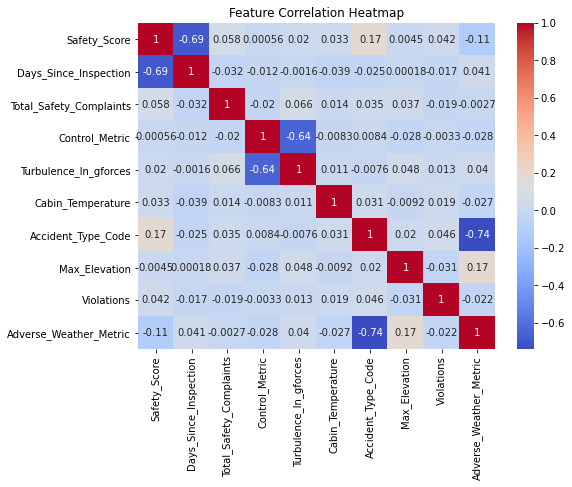

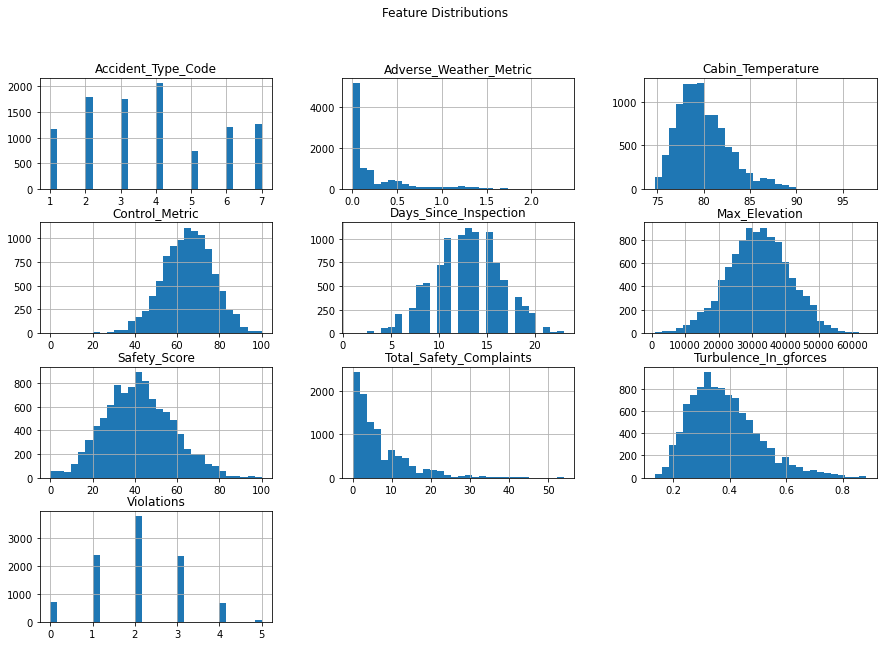


 Encoded Target Classes Mapping:
{'Highly_Fatal_And_Damaging': 0, 'Minor_Damage_And_Injuries': 1, 'Significant_Damage_And_Fatalities': 2, 'Significant_Damage_And_Serious_Injuries': 3}


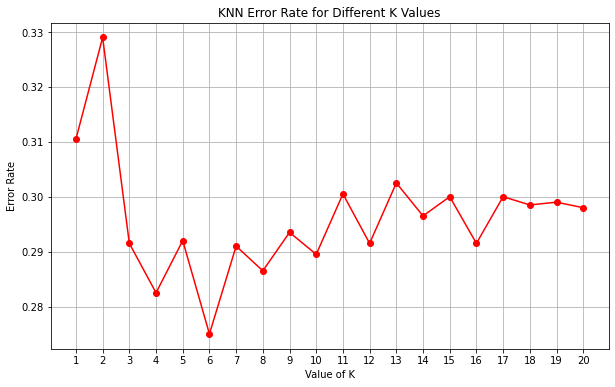


Best K = 6 with Error Rate = 0.2750


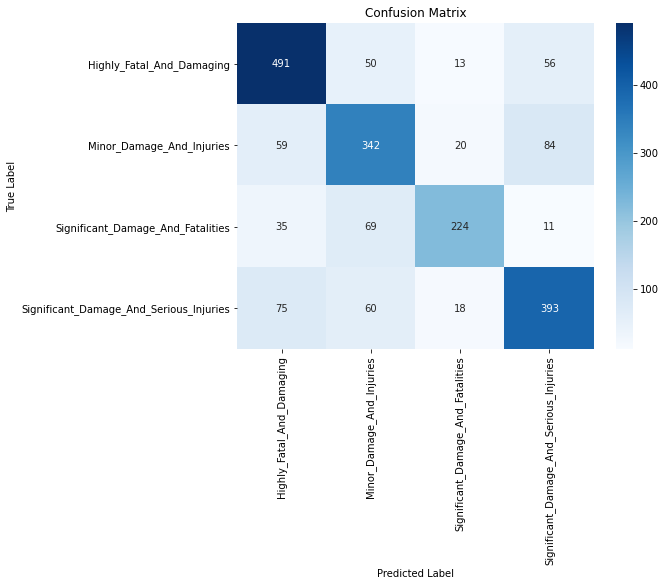


 Classification Report:
                                         precision    recall  f1-score   support

              Highly_Fatal_And_Damaging       0.74      0.80      0.77       610
              Minor_Damage_And_Injuries       0.66      0.68      0.67       505
      Significant_Damage_And_Fatalities       0.81      0.66      0.73       339
Significant_Damage_And_Serious_Injuries       0.72      0.72      0.72       546

                               accuracy                           0.73      2000
                              macro avg       0.73      0.72      0.72      2000
                           weighted avg       0.73      0.72      0.72      2000

Cross-Validation Accuracy Scores: [0.71205759 0.71025795 0.74565087 0.70845831 0.70048019 0.70468187]
Average Accuracy Across Folds: 0.7136
Standard Deviation: 0.0148


In [1]:
#1- K-NN 
# importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# importing data
df = pd.read_csv("Airplane accidents severity.csv")
# first few rows.
df.head()
# columns of the dataset
df.columns
# information obout the data
df.info()
# missing observations
df.isna().sum()
# Check for Duplicates
print("\n Number of Duplicate Rows:")
print(df.duplicated().sum())
# Unique Classes in Target
print("\n Unique 'Severity' Labels:")
print(df['Severity'].value_counts(normalize=True)) 
# Drop irrelacant features
df.drop(['Accident_ID'],axis=1,inplace=True)
plt.figure(figsize=(8, 6))
sns.heatmap(df.drop(['Severity'], axis=1).corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()
# Distribution of Features
numerical_features = df.select_dtypes(include=['float64', 'int64']).columns
df[numerical_features].hist(figsize=(15, 10), bins=30)
plt.suptitle("Feature Distributions")
plt.show()
# Encode Target
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Severity_encoded'] = le.fit_transform(df['Severity'])
print("\n Encoded Target Classes Mapping:")
print(dict(zip(le.classes_, le.transform(le.classes_))))
df = df.drop('Severity', axis=1)
X = df.drop('Severity_encoded', axis=1)
y = df['Severity_encoded']
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Different values of K and store error rates
k_range = range(1, 21)
errors = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred_k = knn.predict(X_test)
    error = 1 - accuracy_score(y_test, y_pred_k)
    errors.append(error)

# Plot Error vs K
plt.figure(figsize=(10, 6))
plt.plot(k_range, errors, marker='o', color='red')
plt.xticks(k_range)
plt.xlabel('Value of K')
plt.ylabel('Error Rate')
plt.title('KNN Error Rate for Different K Values')
plt.grid(True)
plt.show()

# Best K (lowest error)
optimal_k = k_range[errors.index(min(errors))]
print(f"\nBest K = {optimal_k} with Error Rate = {min(errors):.4f}")

# final model with optimal K
knn_final = KNeighborsClassifier(n_neighbors=optimal_k)
knn_final.fit(X_train, y_train)
y_pred = knn_final.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# Classification Report
print("\n Classification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Cross-Validation
from sklearn.model_selection import cross_val_score

# final KNN model with best K = 6
knn_cv = KNeighborsClassifier(n_neighbors=6)

# cross-validation
cv_scores = cross_val_score(knn_cv, X_scaled, y, cv=6, scoring='accuracy')

# Print results
print("Cross-Validation Accuracy Scores:", cv_scores)
print("Average Accuracy Across Folds:", np.mean(cv_scores).round(4))
print("Standard Deviation:", np.std(cv_scores).round(4))

Best Parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Number of support vectors: 3253
Accuracy: 90.05%
Precision: 90.05%
Recall: 90.05%


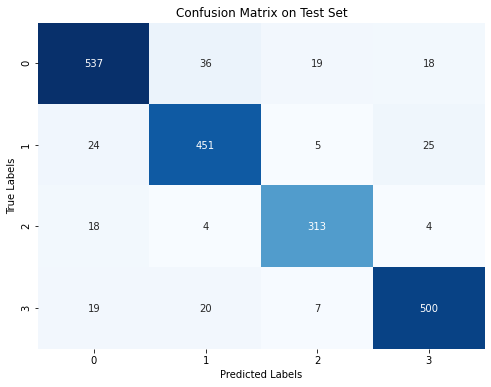

Classification Report:
                                          precision    recall  f1-score   support

              Highly_Fatal_And_Damaging       0.90      0.88      0.89       610
              Minor_Damage_And_Injuries       0.88      0.89      0.89       505
      Significant_Damage_And_Fatalities       0.91      0.92      0.92       339
Significant_Damage_And_Serious_Injuries       0.91      0.92      0.91       546

                               accuracy                           0.90      2000
                              macro avg       0.90      0.90      0.90      2000
                           weighted avg       0.90      0.90      0.90      2000

Cross-validation scores: [0.915   0.8975  0.89125 0.9     0.89   ]
Mean CV accuracy: 0.8987499999999999


In [2]:
#2-SVM
# This cell loads all necessary libraries for data processing, model building (using SVM), evaluation, and visualization.
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
df = pd.read_csv("Airplane accidents severity.csv") # Load dataset
df = df.drop(columns=['Accident_ID']) # Drop the unique ID since it does not contribute to prediction

# Encode the target variable (Severity)
label_encoder = LabelEncoder()
df['Severity'] = label_encoder.fit_transform(df['Severity'])

# Split into features and target
X = df.drop(columns=['Severity']) # Features
Y = df['Severity'] # Target variable

# Train-test split (80% training, 20% testing)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)
# 'stratify=Y' ensures the class distribution is preserved in both sets.

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
# Define the grid of hyperparameters to search through
parameters = {
    'C': [0.1, 1, 10],  # Regularization strength
    'kernel': ['linear', 'rbf', 'poly'],  # Different kernel types to test
    'gamma': ['scale', 'auto']  # Kernel coefficient for 'rbf' and 'poly'
}

# Perform grid search with cross-validation to find the best parameters
svm_grid = GridSearchCV(SVC(), parameters, cv=5, scoring='accuracy', n_jobs=-1)
svm_grid.fit(X_train_scaled, Y_train) # Train on scaled training data

# Print best parameters
print("Best Parameters:", svm_grid.best_params_)
# Train SVM model with best kernel and parameters
svm_model = SVC(kernel='rbf', C=10, random_state=42)
svm_model.fit(X_train_scaled, Y_train)

# Number of support vectors
num_support_vectors = len(svm_model.support_)
print(f"Number of support vectors: {num_support_vectors}")
# Predict on the test set using the trained model
Y_pred = svm_model.predict(X_test_scaled)

# Compute evaluation metrics
conf_matrix = confusion_matrix(Y_test, Y_pred)
accuracy = accuracy_score(Y_test, Y_pred)
precision = precision_score(Y_test, Y_pred, average='weighted')
recall = recall_score(Y_test, Y_pred, average='weighted')

# Display results
print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall: {recall * 100:.2f}%")

# Plot the confusion matrix
plt.figure(figsize= (8, 6))
sns.heatmap (conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False, xticklabels=np.unique(Y_test), yticklabels=np.unique(Y_test))
plt.title("Confusion Matrix on Test Set")
plt.xlabel("Predicted Labels") 
plt.ylabel("True Labels")
plt.show()

# classification report
class_report = classification_report(Y_test, Y_pred, target_names=label_encoder.classes_)
print('Classification Report:\n', class_report)
cross_val = cross_val_score(svm_model, X_train_scaled, Y_train, cv=5)
print("Cross-validation scores:", cross_val)
print("Mean CV accuracy:", cross_val.mean())

Random Forest - Test Accuracy: 0.9345
Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.93      0.94       610
           1       0.90      0.93      0.92       505
           2       0.92      0.94      0.93       339
           3       0.95      0.94      0.94       546

    accuracy                           0.93      2000
   macro avg       0.93      0.93      0.93      2000
weighted avg       0.93      0.93      0.93      2000



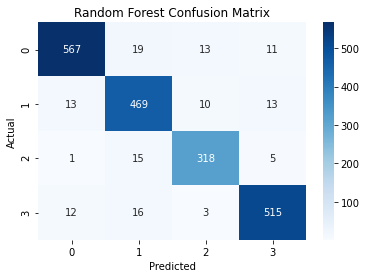


Cross-validation scores: [0.9225   0.915    0.916875 0.9175   0.915   ]
Mean cross-validation accuracy: 0.9174


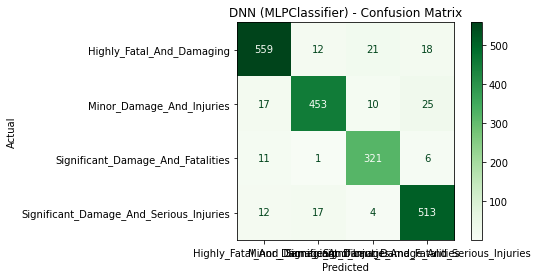

DNN Accuracy: 0.9230
DNN Precision: 0.9235
DNN Recall: 0.9230
DNN F1 Score: 0.9230

DNN - TP, FP, FN, TN per class:
Class 'Highly_Fatal_And_Damaging': TP=559, FP=40, FN=51, TN=1350
Class 'Minor_Damage_And_Injuries': TP=453, FP=30, FN=52, TN=1465
Class 'Significant_Damage_And_Fatalities': TP=321, FP=35, FN=18, TN=1626
Class 'Significant_Damage_And_Serious_Injuries': TP=513, FP=49, FN=33, TN=1405


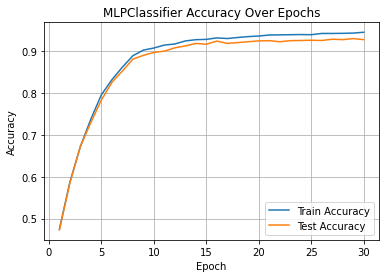

In [3]:
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score, classification_report

# << Load and preprocess dataset >>
df = pd.read_csv('/Users/zm/Desktop/Airplane accidents severity.csv')

label_encoder = LabelEncoder()
df['Severity_encoded'] = label_encoder.fit_transform(df['Severity'])

X = df.drop(columns=['Severity', 'Severity_encoded', 'Accident_ID'])
y = df['Severity_encoded']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# << Random Forest Model >>
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)
y_pred_rf = rf_model.predict(X_test_scaled)

print("Random Forest - Test Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Classification Report:\n", classification_report(y_test, y_pred_rf))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Blues')
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# << DNN Model Training >>
dnn_model = MLPClassifier(hidden_layer_sizes=(64, 32), activation='relu', solver='adam',
                          max_iter=300, batch_size=32, random_state=42)
dnn_model.fit(X_train_scaled, y_train)

# << Cross-Validation for DNN >>
dnn_cv_model = MLPClassifier(hidden_layer_sizes=(64, 32), activation='relu',
                             solver='adam', max_iter=300, batch_size=32, random_state=42)
cv_scores = cross_val_score(dnn_cv_model, X_train_scaled, y_train, cv=5, scoring='accuracy')
print("\nCross-validation scores:", cv_scores)
print(f"Mean cross-validation accuracy: {cv_scores.mean():.4f}")

# << DNN Evaluation >>
y_pred_dnn = dnn_model.predict(X_test_scaled)
labels = label_encoder.classes_
cm_dnn = confusion_matrix(y_test, y_pred_dnn)

# <<Confusion Matrix Plot>>
disp = ConfusionMatrixDisplay(confusion_matrix=cm_dnn, display_labels=labels)
disp.plot(cmap='Greens')
plt.title("DNN (MLPClassifier) - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# <<Accuracy, Precision, Recall, F1>>
acc_dnn = accuracy_score(y_test, y_pred_dnn)
precision_dnn = precision_score(y_test, y_pred_dnn, average='weighted')
recall_dnn = recall_score(y_test, y_pred_dnn, average='weighted')
f1_dnn = f1_score(y_test, y_pred_dnn, average='weighted')

print(f"DNN Accuracy: {acc_dnn:.4f}")
print(f"DNN Precision: {precision_dnn:.4f}")
print(f"DNN Recall: {recall_dnn:.4f}")
print(f"DNN F1 Score: {f1_dnn:.4f}")

# <<TP, FP, FN, TN per class>>
print("\nDNN - TP, FP, FN, TN per class:")
for i, label in enumerate(labels):
    TP = cm_dnn[i, i]
    FP = cm_dnn[:, i].sum() - TP
    FN = cm_dnn[i, :].sum() - TP
    TN = cm_dnn.sum() - (TP + FP + FN)
    print(f"Class '{label}': TP={TP}, FP={FP}, FN={FN}, TN={TN}")

# << Accuracy Visualization >>
train_scores = []
test_scores = []

for i in range(1, 31):
    model_temp = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=i, solver='adam', activation='relu', random_state=42, warm_start=True)
    model_temp.fit(X_train_scaled, y_train)
    train_scores.append(model_temp.score(X_train_scaled, y_train))
    test_scores.append(model_temp.score(X_test_scaled, y_test))

plt.plot(range(1, 31), train_scores, label='Train Accuracy')
plt.plot(range(1, 31), test_scores, label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('MLPClassifier Accuracy Over Epochs ')
plt.legend()
plt.grid(True)
plt.show()
